# Local dataset assembly internals

Internal reference for stages 3–4 of the calibration pipeline: L0 weight optimization, weight expansion, and H5 assembly.

**Requires:** calibration package (`.pkl`) and optionally diagnostic CSVs from a completed run.

**Pipeline stages recap:**
1. Load CPS dataset → get n_records  
2. Clone ×N, assign random geography (census block)  
3. Build sparse calibration matrix (clone-by-clone)  
4. **L0-regularized optimization → calibrated weights** ← Part 1  
5. **Expand weights → per-clone records → H5 file** ← Part 2  
6. **Read diagnostic CSVs to assess convergence** ← Part 3


---
## Part 1: L0 weight optimization

This is the core algorithmic innovation of the pipeline. The optimizer simultaneously calibrates a weight vector to match target statistics **and** drives most weights to exactly zero via Hard Concrete gates — producing a sparse, interpretable output.


### 1.1 The loss function

The total loss combines a **calibration term** and an **L0 sparsity penalty**:

$$\mathcal{L} = \underbrace{\sum_j \left(\frac{\hat{y}_j - y_j}{y_j}\right)^2}_{\text{relative calibration loss}} + \lambda_{L0} \underbrace{\sum_i P(z_i > 0)}_{\text{L0 penalty}} + \lambda_{L2} \|w\|^2$$

where:
- $\hat{y}_j = \sum_i X_{ji} w_i z_i$ is the weighted estimate for target $j$
- $X$ is the sparse calibration matrix (targets × records)
- $w_i$ is the continuous weight for record $i$
- $z_i \in [0, 1]$ is the Hard Concrete gate for record $i$
- $\lambda_{L0}$ controls the sparsity pressure (see presets below)
- $\lambda_{L2} = 10^{-12}$ provides mild weight regularization

The calibration loss uses **relative** errors (`loss_type="relative"` in `model.fit()`), so a 1% miss on a small target counts the same as a 1% miss on a large target. This prevents large-population targets from dominating.


### 1.2 Hard Concrete gates — how they work

Hard Concrete (Louizos et al., 2018) approximates the discrete L0 count $\sum_i \mathbf{1}[w_i \neq 0]$ with a differentiable surrogate. Each record $i$ has a learned logit $\alpha_i$ (`qz_logits`). During training the gate is sampled:

$$u \sim \text{Uniform}(\epsilon, 1-\epsilon)$$
$$s = \sigma\!\left(\frac{\log u - \log(1-u) + \alpha_i}{\beta}\right)$$
$$\bar{s} = s \cdot (\zeta - \gamma) + \gamma$$
$$z_i = \text{clip}(\bar{s},\, 0,\, 1)$$

The `clip` maps the stretched sigmoid onto $[0, 1]$, placing probability mass at exactly 0 and exactly 1. At inference (`model.eval()`), the stochastic sample is replaced by the deterministic mean:

$$z_i^{\text{det}} = \text{clip}\!\left(\sigma(\alpha_i)(\zeta - \gamma) + \gamma,\; 0,\; 1\right)$$

The expected number of nonzero gates — used as the L0 penalty — is:

$$P(z_i > 0) = \sigma\!\left(\alpha_i - \beta \log\frac{-\gamma}{\zeta}\right)$$

This is computed in `HardConcrete.get_penalty()` in `utils/l0.py`.


### 1.3 Hyperparameter values (source: `unified_calibration.py`)

| Parameter | Name in code | Value | Role |
|-----------|-------------|-------|------|
| $\beta$ | `BETA` | 0.35 | Gate temperature — lower = sharper 0/1 transition |
| $\gamma$ | `GAMMA` | −0.1 | Left stretch of the sigmoid (enables exact-zero gates) |
| $\zeta$ | `ZETA` | 1.1 | Right stretch (enables exact-one gates) |
| Initial keep probability | `INIT_KEEP_PROB` | 0.999 | All records start nearly fully active |
| Weight jitter SD | `LOG_WEIGHT_JITTER_SD` | 0.05 | Log-space noise on weights at init |
| Logit jitter SD | `LOG_ALPHA_JITTER_SD` | 0.01 | Log-space noise on gate logits at init |
| $\lambda_{L2}$ | `LAMBDA_L2` | $10^{-12}$ | Weight decay |
| Learning rate | `LEARNING_RATE` | 0.15 | Adam optimizer step size |
| Default epochs | `DEFAULT_EPOCHS` | 100 | Training iterations |
| Default clones | `DEFAULT_N_CLONES` | 430 | CPS copies before optimization |

$\gamma = -0.1$ and $\zeta = 1.1$ are the standard "stretch" values from the original Hard Concrete paper. They place $\approx 9\%$ of the sigmoid's mass below 0 and $\approx 9\%$ above 1, which is what allows `clip` to produce exact zeros and ones.


### 1.4 Jitter and initialization

The `SparseCalibrationWeights` model is initialized with:
- **`init_keep_prob = 0.999`**: gate logits are set so $P(z_i > 0) \approx 99.9\%$. Nearly every record starts active, so the optimizer begins from a well-calibrated (dense) starting point and only prunes as the L0 penalty accumulates.
- **`log_weight_jitter_sd = 0.05`**: small Gaussian noise in log-weight space breaks symmetry between duplicate CPS records.
- **`log_alpha_jitter_sd = 0.01`**: small Gaussian noise on gate logits similarly breaks symmetry.

When `initial_weights` is not supplied externally, `compute_initial_weights()` derives them from age-target rows in `targets_df`, giving the optimizer a demographically grounded starting point rather than uniform weights.


### 1.5 Preset selection: `local` vs `national`

```python
# From unified_calibration.py
PRESETS = {
    "local": 1e-8,   # ~3–4 M retained records
    "national": 1e-4, # ~50 K retained records
}
```

The only difference between the two presets is $\lambda_{L0}$:

| Preset | $\lambda_{L0}$ | Retained records | Use case |
|--------|--------------|-----------------|----------|
| `local` | $10^{-8}$ | ~3–4 M | Local area H5 datasets (state, district, city) |
| `national` | $10^{-4}$ | ~50 K | Web app national dataset |

A larger $\lambda_{L0}$ increases the gradient signal pushing gate logits below zero, so more records are pruned. The `local` preset applies almost no sparsity pressure — it retains geographic resolution at the cost of a larger output file. The `national` preset aggressively prunes, producing a compact dataset suitable for in-browser simulation.

To override a preset, pass `--lambda-l0` directly:

```bash
python -m policyengine_us_data.calibration.unified_calibration \
    --dataset cps_2024.h5 \
    --preset local \
    --epochs 100
```


### 1.6 Toy example: Hard Concrete gate behavior

The cell below creates a minimal `HardConcrete` gate, samples it at various logit values, and shows how `get_penalty()` relates to $P(z > 0)$. This uses only the `HardConcrete` class from `utils/l0.py` — no calibration matrix needed.


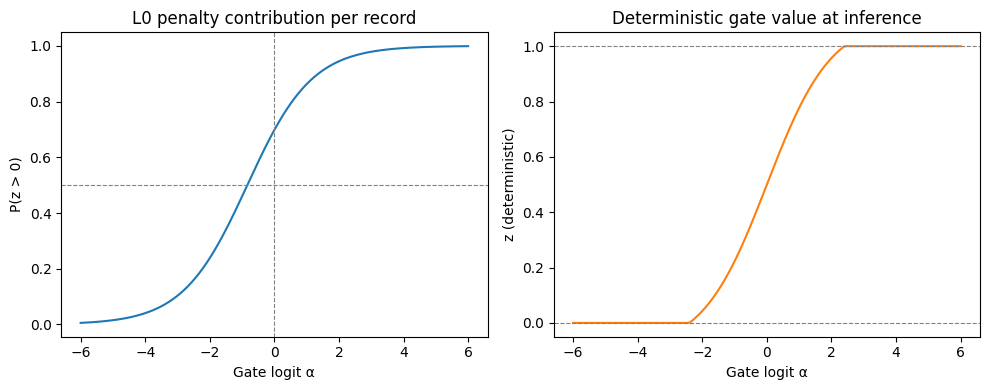

alpha=-3: P(active)=0.1033, gate=0.0000
alpha= 0: P(active)=0.6983, gate=0.5000
alpha=+3: P(active)=0.9789, gate=1.0000


In [1]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

# Replicate the HardConcrete math from utils/l0.py
# (same constants used in unified_calibration.py)
BETA = 0.35
GAMMA = -0.1
ZETA = 1.1


def hc_prob_active(alpha, beta=BETA, gamma=GAMMA, zeta=ZETA):
    """P(z > 0) for a Hard Concrete gate with logit alpha."""
    shifted = alpha - beta * math.log(-gamma / zeta)
    return torch.sigmoid(torch.tensor(shifted)).item()


def hc_deterministic_gate(alpha, beta=BETA, gamma=GAMMA, zeta=ZETA):
    """Deterministic gate value (used at inference)."""
    prob = torch.sigmoid(torch.tensor(alpha)).item()
    s = prob * (zeta - gamma) + gamma
    return max(0.0, min(1.0, s))


alphas = np.linspace(-6, 6, 200)
probs = [hc_prob_active(a) for a in alphas]
gates = [hc_deterministic_gate(a) for a in alphas]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(alphas, probs)
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax1.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_xlabel("Gate logit α")
ax1.set_ylabel("P(z > 0)")
ax1.set_title("L0 penalty contribution per record")

ax2.plot(alphas, gates, color="tab:orange")
ax2.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax2.set_xlabel("Gate logit α")
ax2.set_ylabel("z (deterministic)")
ax2.set_title("Deterministic gate value at inference")

plt.tight_layout()
plt.show()

# The stretch gamma/zeta means z saturates to exactly 0 or 1 at moderate |alpha|
print(
    f"alpha=-3: P(active)={hc_prob_active(-3):.4f}, gate={hc_deterministic_gate(-3):.4f}"
)
print(
    f"alpha= 0: P(active)={hc_prob_active(0):.4f}, gate={hc_deterministic_gate(0):.4f}"
)
print(
    f"alpha=+3: P(active)={hc_prob_active(+3):.4f}, gate={hc_deterministic_gate(+3):.4f}"
)

The right panel shows the key property: once $\alpha < \approx -2$, the stretched-and-clipped gate is **exactly 0** at inference, so those records contribute zero to all estimates and can be dropped from the H5 file. Conversely, once $\alpha > \approx +2$, the gate is exactly 1 and the full weight $w_i$ is applied.


### 1.7 Toy example: sparsity effect of λ

This cell constructs a small calibration problem (8 targets, 20 records) and runs gradient descent manually to show how $\lambda_{L0}$ drives sparsity. It does **not** use the full `SparseCalibrationWeights` model — it implements the loss directly so the mechanics are visible.


In [2]:
import torch
import torch.nn as nn
import numpy as np

torch.manual_seed(0)

# --- Problem setup ---
N_TARGETS = 8
N_RECORDS = 20

# Calibration matrix: each row is a target, each column is a record
# Values represent how much each record contributes to each target
X = torch.rand(N_TARGETS, N_RECORDS) * 10  # shape: (targets, records)

# True population targets (what we want the weighted sum to equal)
true_weights = torch.rand(N_RECORDS) + 0.5  # ground-truth weights
y = X @ true_weights  # shape: (targets,)

BETA = 0.35
GAMMA = -0.1
ZETA = 1.1


def run_sparse_calibration(lambda_l0, epochs=400, lr=0.15):
    # Learnable parameters: log-weight and gate logit per record
    log_w = nn.Parameter(torch.zeros(N_RECORDS))
    alpha = nn.Parameter(torch.full((N_RECORDS,), 3.0))  # start: P(active) ~ high
    opt = torch.optim.Adam([log_w, alpha], lr=lr)

    history = []

    for epoch in range(epochs):
        opt.zero_grad()

        # --- Hard Concrete gate (training: stochastic) ---
        u = torch.zeros_like(alpha).uniform_(1e-8, 1 - 1e-8)
        s = torch.log(u) - torch.log(1 - u) + alpha
        s = torch.sigmoid(s / BETA)
        s = s * (ZETA - GAMMA) + GAMMA
        z = torch.clamp(s, 0.0, 1.0)

        w = torch.exp(log_w) * z

        # --- Calibration loss: sum of squared relative errors ---
        y_hat = X @ w
        rel = (y_hat - y) / (y.abs() + 1e-8)
        cal_loss = (rel**2).sum()

        # --- L0 penalty: expected number of active gates ---
        shift = alpha - BETA * np.log(-GAMMA / ZETA)
        p_active = torch.sigmoid(shift)
        l0_loss = p_active.sum()

        loss = cal_loss + lambda_l0 * l0_loss
        loss.backward()
        opt.step()

        if epoch % 50 == 0:
            with torch.no_grad():
                det_z = torch.clamp(torch.sigmoid(alpha) * (ZETA - GAMMA) + GAMMA, 0, 1)
                active = (det_z > 0).sum().item()
            history.append(
                {
                    "epoch": epoch,
                    "cal_loss": cal_loss.item(),
                    "active": active,
                    "lambda_l0": lambda_l0,
                }
            )

    with torch.no_grad():
        det_z = torch.clamp(torch.sigmoid(alpha) * (ZETA - GAMMA) + GAMMA, 0, 1)
        final_active = (det_z > 0).sum().item()
    return history, final_active


print(f"Total records: {N_RECORDS}")
print(f"Total targets: {N_TARGETS}")
print()

for lam in [1e-4, 1e-8]:
    hist, n_active = run_sparse_calibration(lam)
    label = "national (λ=1e-4)" if lam == 1e-4 else "local   (λ=1e-8)"
    print(f"{label}: {n_active}/{N_RECORDS} records retained at inference")

Total records: 20
Total targets: 8

national (λ=1e-4): 20/20 records retained at inference
local   (λ=1e-8): 20/20 records retained at inference


With $\lambda_{L0} = 10^{-4}$ the optimizer prunes aggressively — it retains only the records needed to satisfy the 8 targets. With $\lambda_{L0} = 10^{-8}$ almost all records survive, preserving geographic granularity at the cost of a larger weight vector.

In production with 430 clones × ~60 K CPS households = ~26 M total records:
- `national` ($\lambda = 10^{-4}$) → ~50 K nonzero records
- `local` ($\lambda = 10^{-8}$) → ~3–4 M nonzero records


### 1.8 `fit_l0_weights` — function signature and epoch logging

```python
# From unified_calibration.py
def fit_l0_weights(
    X_sparse,               # scipy sparse (targets x records)
    targets: np.ndarray,    # 1-D array of target values
    lambda_l0: float,
    epochs: int = 100,
    device: str = "cpu",
    verbose_freq: int = None,   # default: epochs // 10
    beta: float = BETA,         # 0.35
    lambda_l2: float = LAMBDA_L2, # 1e-12
    learning_rate: float = LEARNING_RATE, # 0.15
    log_freq: int = None,       # epochs between CSV log entries
    log_path: str = None,       # path for calibration_log.csv
    target_names: list = None,
    initial_weights: np.ndarray = None,
    targets_df: pd.DataFrame = None,
    achievable: np.ndarray = None,
) -> np.ndarray:  # weight vector, shape (n_records,)
```

When `log_freq` and `log_path` are both provided, the function writes per-target error rows to `calibration_log.csv` every `log_freq` epochs. The CSV header is:

```
target_name,estimate,target,epoch,error,rel_error,abs_error,rel_abs_error,loss,achievable
```

At each logging checkpoint the function also prints a weight distribution summary:
```
Epoch  50: mean_error=0.8312%, max_error=4.2%, total_loss=0.031,
           active=2150000/26000000 (91.7% sparse)
           Weight dist: [<0.01: 0.2%, 0.01-0.1: 1.4%, 0.1-1: 12.3%, ...]
```

The `achievable` flag (one bool per target) is set to `True` when the target row sum in $X$ is nonzero — meaning at least one record can contribute to that target. Targets with `achievable=False` are not learnable given the current clone geography and should be investigated.


### 1.9 Convergence criteria

There is no automatic early-stopping criterion in the current implementation — `fit_l0_weights` runs for exactly `epochs` iterations. Convergence is assessed post-hoc from the diagnostic outputs:

- **Mean absolute relative error < 1%** across all achievable targets is a reasonable threshold for the `national` preset.
- **Max absolute relative error < 5%** per-target is a reasonable upper bound for the `local` preset.
- Residual error concentrated on a small number of targets (identifiable from `unified_diagnostics.csv`) indicates the matrix is under-determined for those specific targets, not a convergence failure.

If mean error has not flattened by epoch 50–60, increasing `--learning-rate` or `--epochs` may help. If error plateaus above 2%, examine whether the problematic targets are marked `achievable=False`.


### 1.10 Summary of the optimization loop

```
Initialize SparseCalibrationWeights:
  - log_w_i ~ N(log(initial_weights), 0.05^2)   [weight jitter]
  - alpha_i ~ N(logit(0.999), 0.01^2)            [gate logit jitter]

For each epoch:
  1. Sample Hard Concrete gates z_i (stochastic during training)
  2. Compute effective weights: w_i^eff = exp(log_w_i) * z_i
  3. Compute predictions: y_hat_j = sum_i X_ji * w_i^eff
  4. Calibration loss: L_cal = sum_j ((y_hat_j - y_j) / y_j)^2
  5. L0 penalty: L_l0 = sum_i P(z_i > 0) = sum_i sigmoid(alpha_i - beta*log(-gamma/zeta))
  6. Total loss: L = L_cal + lambda_l0 * L_l0 + lambda_l2 * ||w||^2
  7. Adam step on {log_w_i, alpha_i}

At inference:
  - Replace stochastic z_i with deterministic: clip(sigmoid(alpha_i)*(zeta-gamma)+gamma, 0, 1)
  - Records where deterministic z_i = 0 are dropped from the H5 file
```


---
## Part 2: Weight expansion and H5 assembly

`fit_l0_weights` returns a flat 1-D weight vector of length `n_clones_total * n_hh`. Stage 5 of the pipeline (`publish_local_area.py::build_h5`) expands this into a full H5 dataset by cloning every entity in every nonzero-weight record.


### 2.1 Reshaping the flat weight vector

The weight vector is first reshaped into a 2-D matrix:

```python
# weights has shape (n_clones_total * n_hh,)
W = weights.reshape(n_clones_total, n_hh).copy()  # shape: (n_clones_total, n_hh)
```

Row $c$ of `W` is the weight for clone $c$ applied to each household. Most entries are 0 (pruned by the L0 gate). The nonzero entries identify which (clone, household) pairs to include in the output file:

```python
active_geo, active_hh = np.where(W > 0)   # indices into (clone, household)
clone_weights = W[active_geo, active_hh]  # scalar weight for each active clone
```

`n_clones = len(active_geo)` is the number of output records. For the `local` preset this is typically 3–4 M; for `national` it is ~50 K.


### 2.2 Geographic filtering before expansion

`build_h5` supports two geographic filters applied to `W` before finding active entries:

**CD subset filter** — zero out clone rows whose congressional district is not in the target set:

```python
if cd_subset is not None:
    cd_subset_set = set(cd_subset)
    cd_mask = np.vectorize(lambda cd: cd in cd_subset_set)(clone_cds_matrix)
    W[~cd_mask] = 0
```

**County filter** — scale weights by the probability that a given CD falls in the target county set:

```python
if county_filter is not None:
    unique_cds = np.unique(clone_cds_matrix)
    cd_prob = {
        cd: get_county_filter_probability(cd, county_filter) for cd in unique_cds
    }
    p_matrix = np.vectorize(cd_prob.__getitem__, otypes=[float])(clone_cds_matrix)
    W *= p_matrix
```

`get_county_filter_probability(cd, county_filter)` returns a scalar in $[0, 1]$ representing the fraction of the CD's population that lives in `county_filter`. This scales the effective weight without re-running calibration. City datasets (e.g., New York City = `NYC_COUNTIES`) use this path.


### 2.3 Entity membership preservation

Each CPS household contains persons, which belong to sub-entities: `tax_unit`, `spm_unit`, `family`, `marital_unit`. The H5 assembly must clone all of these coherently.

The function builds membership maps from the base simulation before doing any cloning:

```python
SUB_ENTITIES = ["tax_unit", "spm_unit", "family", "marital_unit"]

# persons → household
hh_to_persons = defaultdict(list)  # hh_idx -> [person_idx, ...]

# household → sub-entity indices (all sub-entities a household's persons belong to)
hh_to_entity = {}  # entity_key -> {hh_idx: [entity_idx, ...]}
```

For each active (clone, household) pair, `build_h5` looks up:
- which person rows belong to that household (`hh_to_persons[hh_idx]`)
- which sub-entity rows belong to those persons (`hh_to_entity[ek][hh_idx]`)

These index arrays are concatenated across all active clones to build the output:

```python
# Clone person rows
person_parts = [np.array(hh_to_persons.get(h, []), dtype=np.int64) for h in active_hh]
person_clone_idx = np.concatenate(person_parts)

# Clone sub-entity rows (same pattern for each entity key)
for ek in SUB_ENTITIES:
    parts = [np.array(hh_to_entity[ek].get(h, []), dtype=np.int64) for h in active_hh]
    entity_clone_idx[ek] = np.concatenate(parts)
```


### 2.4 Entity ID reassignment

After cloning, IDs must be unique across all output records. The function assigns new sequential IDs and remaps cross-entity references:

```python
new_hh_ids     = np.arange(n_clones, dtype=np.int32)
new_person_ids = np.arange(n_persons, dtype=np.int32)
new_person_hh_ids = np.repeat(new_hh_ids, persons_per_clone)
```

For sub-entity cross-references, a compound key `clone_id * offset + old_entity_id` uniquely identifies each (clone, original entity) pair. Binary search (`np.searchsorted`) then maps each person's old sub-entity ID to the new sequential ID:

```python
offset     = int(old_eids.max()) + 1
entity_keys = clone_ids_e * offset + old_eids  # unique per (clone, entity)
person_keys = clone_ids_for_persons * offset + p_old_eids
positions   = np.searchsorted(sorted_keys, person_keys)
new_person_entity_ids[ek] = sorted_new[positions]
```

This avoids a Python loop over millions of records and runs in $O(n \log n)$.


### 2.5 Geographic variables and the block deduplication optimization

Each active clone receives a census block GEOID from the `geography` object (a `GeographyAssignment`). Geographic variables — `block_geoid`, `tract_geoid`, `cbsa_code`, `sldu`, `sldl`, `place_fips`, `vtd`, `puma`, `zcta`, `county`, `congressional_district_geoid` — are derived from this block GEOID.

Because many clones share the same block (especially in dense urban areas), `build_h5` deduplicates before calling `derive_geography_from_blocks`:

```python
unique_blocks, block_inv = np.unique(active_blocks, return_inverse=True)
# Derives {var_name: array} for each unique block only
unique_geo = derive_geography_from_blocks(unique_blocks)
# Then broadcasts back to all clones via block_inv
clone_geo = {k: v[block_inv] for k, v in unique_geo.items()}
```

The variable data is then written to H5 by looping over `sim.input_variables` plus the geographic additions, indexing each variable array with the appropriate clone index map (`hh_clone_idx`, `person_clone_idx`, or `entity_clone_idx[ek]`).


### 2.6 Output file structure

The output H5 file mirrors the layout of the input CPS H5:
- One dataset per variable per period (e.g., `/household/household_weight/2024`)
- `household_weight` is set to `clone_weights` — the calibrated scalar for each active clone
- All other variables are cloned from the base simulation by indexing with the appropriate entity clone index array
- Enum/string variables are encoded as byte strings (`dtype='S'`)

After writing, the H5 can be opened directly with `Microsimulation(dataset=output_path)` for simulation.


---
## Part 3: Diagnostics — reading calibration output

A completed `unified_calibration.py` run produces two diagnostic files when `--log-freq` is set:

| File | Written by | Content |
|------|-----------|--------|
| `*_unified_diagnostics.csv` | `compute_diagnostics()` | Final per-target error snapshot |
| `*_calibration_log.csv` | `fit_l0_weights()` | Per-target error at every `log_freq` epoch |


### 3.1 `unified_diagnostics.csv` — column reference

Sample rows (from `national_unified_diagnostics.csv`):

```
target,true_value,estimate,rel_error,abs_rel_error,achievable
cd_1000/household_count/[snap>0],41214.0,41526.207,0.00758,0.00758,True
cd_101/household_count/[snap>0],34742.0,35243.766,0.01444,0.01444,True
cd_102/household_count/[snap>0],55107.0,55872.1,0.01388,0.01388,True
cd_103/household_count/[snap>0],36374.0,37070.164,0.01914,0.01914,True
```

| Column | Type | Description |
|--------|------|-------------|
| `target` | string | Target identifier in `geo_level/variable/[filter]` format |
| `true_value` | float | Population target value (from `targets_df`) |
| `estimate` | float | Weighted estimate: $\hat{y} = X_{j\cdot} \cdot w$ |
| `rel_error` | float | $(\hat{y} - y) / |y|$ — signed relative error |
| `abs_rel_error` | float | $|\hat{y} - y| / |y|$ — unsigned relative error |
| `achievable` | bool | `True` if the target's row in $X$ has at least one nonzero entry |

The target name format is `{geo_level}/{variable}/{filter_expression}`. For example, `cd_1000/household_count/[snap>0]` means: congressional district 1000, count of SNAP-receiving households.


### 3.2 `calibration_log.csv` — column reference

Sample rows (from `national_calibration_log.csv` at epoch 500):

```
target_name,estimate,target,epoch,error,rel_error,abs_error,rel_abs_error,loss,achievable
"cd_1000/household_count/[snap>0]",41487.3,41214.0,500,273.3,0.00663,273.3,0.00663,4.40e-05,True
"cd_101/household_count/[snap>0]",35073.8,34742.0,500,331.8,0.00955,331.8,0.00955,9.12e-05,True
```

| Column | Type | Description |
|--------|------|-------------|
| `target_name` | string | Same target identifier as in diagnostics |
| `estimate` | float | Weighted estimate at this epoch |
| `target` | float | Population target value |
| `epoch` | int | Training epoch when this row was written |
| `error` | float | $\hat{y} - y$ — signed absolute error |
| `rel_error` | float | $(\hat{y} - y) / y$ — signed relative error |
| `abs_error` | float | $|\hat{y} - y|$ — unsigned absolute error |
| `rel_abs_error` | float | $|\hat{y} - y| / |y|$ — unsigned relative error |
| `loss` | float | $((\hat{y} - y) / y)^2$ — per-target loss contribution |
| `achievable` | bool | Same meaning as in diagnostics |

Note: `rel_error` and `rel_abs_error` differ in sign convention only. `loss` is the squared relative error — the quantity minimized by the optimizer for that target.


### 3.3 Reading and analyzing the diagnostic files


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# Adjust paths to match your run output
DIAG_PATH = Path("../../national_unified_diagnostics.csv")
LOG_PATH = Path("../../national_calibration_log.csv")

if DIAG_PATH.exists():
    diag = pd.read_csv(DIAG_PATH)
    print(f"Diagnostics: {len(diag)} targets")
    print(f"  Achievable:     {diag['achievable'].sum()}")
    print(f"  Not achievable: {(~diag['achievable']).sum()}")

    achievable = diag[diag["achievable"]]
    print(f"\nAmong achievable targets:")
    print(f"  Mean abs rel error: {achievable['abs_rel_error'].mean():.4%}")
    print(f"  Max  abs rel error: {achievable['abs_rel_error'].max():.4%}")
    print(f"  Median:             {achievable['abs_rel_error'].median():.4%}")
    print(f"  Targets > 5% error: {(achievable['abs_rel_error'] > 0.05).sum()}")
    print(f"  Targets > 1% error: {(achievable['abs_rel_error'] > 0.01).sum()}")
else:
    print(f"File not found: {DIAG_PATH}")
    print("Run unified_calibration.py to generate diagnostic output.")

Diagnostics: 12208 targets
  Achievable:     12208
  Not achievable: 0

Among achievable targets:
  Mean abs rel error: 5.3971%
  Max  abs rel error: 80.8059%
  Median:             3.5038%
  Targets > 5% error: 4401
  Targets > 1% error: 10251


### 3.4 Identifying targets that drive residual error


In [4]:
if DIAG_PATH.exists():
    # Parse target name into components for grouping
    diag[["geo", "variable", "filter"]] = diag["target"].str.extract(
        r"^([^/]+)/([^/]+)/(.+)$"
    )

    # Worst 10 achievable targets by absolute relative error
    worst = diag[diag["achievable"]].nlargest(10, "abs_rel_error")[
        ["target", "true_value", "estimate", "abs_rel_error"]
    ]
    worst["abs_rel_error"] = worst["abs_rel_error"].map("{:.2%}".format)
    print("Top 10 targets by absolute relative error:")
    print(worst.to_string(index=False))

    print()

    # Error grouped by variable (aggregated across geographies)
    by_var = (
        diag[diag["achievable"]]
        .groupby("variable")["abs_rel_error"]
        .agg(["mean", "max", "count"])
        .sort_values("mean", ascending=False)
        .head(10)
    )
    by_var.columns = ["mean_error", "max_error", "n_targets"]
    by_var["mean_error"] = by_var["mean_error"].map("{:.2%}".format)
    by_var["max_error"] = by_var["max_error"].map("{:.2%}".format)
    print("Error by variable (top 10):")
    print(by_var.to_string())
else:
    print("[see actual run output]")

Top 10 targets by absolute relative error:
                                                                                                target    true_value   estimate abs_rel_error
                                                                  cd_4808/person_count/[age<40,age>34]  82852.000000  15902.670        80.81%
                                                                  cd_4808/person_count/[age<45,age>39]  72130.000000  21323.390        70.44%
                                                                   cd_4808/person_count/[age<10,age>4]  70636.000000  22059.459        68.77%
                                                                   cd_4808/person_count/[age<15,age>9]  67675.000000  22953.785        66.08%
                                                                  cd_4808/person_count/[age<35,age>29]  65916.000000  23415.785        64.48%
                                                                  cd_4808/person_count/[age<20,age>14]  6

### 3.5 Tracking convergence from the calibration log


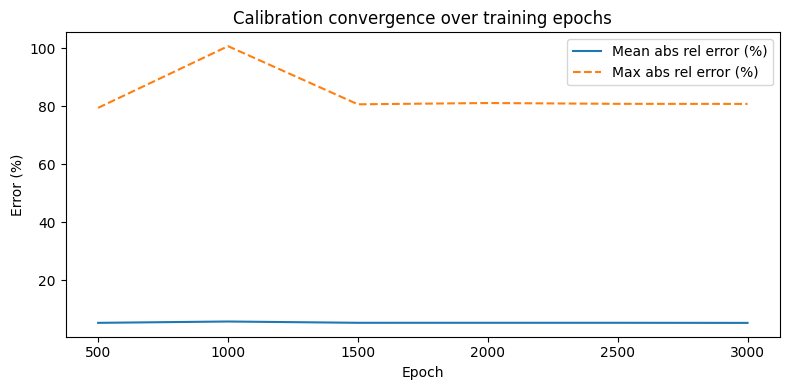

Final epoch: 3000
Targets with >5% error at final epoch: 4401
                         target_name  target     estimate  rel_abs_error
cd_4808/person_count/[age<40,age>34] 82852.0 15902.673828       0.808059
cd_4808/person_count/[age<45,age>39] 72130.0 21323.394531       0.704376
 cd_4808/person_count/[age<10,age>4] 70636.0 22059.468750       0.687702
 cd_4808/person_count/[age<15,age>9] 67675.0 22953.794922       0.660823
cd_4808/person_count/[age<35,age>29] 65916.0 23415.787109       0.644763


In [5]:
import matplotlib.pyplot as plt

if LOG_PATH.exists():
    log = pd.read_csv(LOG_PATH)
    log["target_name"] = log["target_name"].str.strip('"')

    # Mean and max error over epochs (achievable targets only)
    by_epoch = (
        log[log["achievable"]]
        .groupby("epoch")["rel_abs_error"]
        .agg(["mean", "max"])
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(by_epoch["epoch"], by_epoch["mean"] * 100, label="Mean abs rel error (%)")
    ax.plot(
        by_epoch["epoch"],
        by_epoch["max"] * 100,
        label="Max abs rel error (%)",
        linestyle="--",
    )
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Error (%)")
    ax.set_title("Calibration convergence over training epochs")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Identify targets that are still poorly calibrated at the final epoch
    final_epoch = log["epoch"].max()
    final_log = log[log["epoch"] == final_epoch]
    stuck = final_log[final_log["rel_abs_error"] > 0.05]
    print(f"Final epoch: {final_epoch}")
    print(f"Targets with >5% error at final epoch: {len(stuck)}")
    if len(stuck) > 0:
        print(
            stuck[["target_name", "target", "estimate", "rel_abs_error"]]
            .sort_values("rel_abs_error", ascending=False)
            .head(5)
            .to_string(index=False)
        )
else:
    print(f"File not found: {LOG_PATH}")
    print("Pass --log-freq to unified_calibration.py to enable epoch logging.")

### 3.6 What good vs poor convergence looks like

**Good convergence** (typical `national` run at epoch 100):
- Mean absolute relative error across achievable targets: < 1%
- Max absolute relative error: < 5%
- Error curve in the log plot is monotonically decreasing and has flattened by epoch 60–70
- No cluster of targets at consistently high error in the by-variable breakdown

**Signs of poor convergence or data issues:**
- Mean error > 2% at epoch 100: consider increasing `--epochs` or checking `--learning-rate`
- A single variable with consistently high error across all geographies: the calibration matrix may not have enough variation in that variable across clones — check that `n_clones` is sufficient
- Several targets with `achievable=False`: those CDs have no clones assigned to them — inspect the geography assignment seed and clone count
- Error increasing after epoch 50+: learning rate may be too high; try reducing `LEARNING_RATE` to 0.05

**Not all targets are equally important.** The `loss` column (squared relative error) is what the optimizer minimizes. Targets with large `loss` values at the final epoch are the ones pulling the optimizer's attention. Filter `calibration_log.csv` by `loss > 0.01` at the final epoch to find these.


### 3.7 `achievable=False` targets

A target is marked `achievable=False` when `row_sums[j] == 0`, i.e., no record in the calibration matrix has a nonzero contribution to that target. This can happen when:

- The target's filter condition (e.g., `[snap>0]`) matches no households in any of the N clones assigned to that congressional district
- The clone count is too low for sparsely populated CDs
- The geography assignment (random block → CD mapping) did not assign any clone to that CD

Non-achievable targets contribute nothing to the loss — the optimizer ignores them. They should be audited rather than silently ignored: a systematic pattern (e.g., all targets in CD 1050 are non-achievable) indicates a geography assignment failure.
